In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:05<00:00, 32.0MB/s]


In [ ]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 8 -> 4
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 4 -> 8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),    # 16 -> 32
            nn.Tanh()  # Output in [-1,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = EncoderDecoder().to(device)

In [ ]:
criterion = nn.L1Loss()   # Try nn.MSELoss() also
optimizer = optim.Adam(model.parameters(), lr=0.0002)

In [ ]:
epochs = 10

for epoch in range(epochs):
    running_loss = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(loader):.4f}")

Epoch [1/10] Loss: 0.1720
Epoch [2/10] Loss: 0.1013
Epoch [3/10] Loss: 0.0853
Epoch [4/10] Loss: 0.0761
Epoch [5/10] Loss: 0.0698
Epoch [6/10] Loss: 0.0652
Epoch [7/10] Loss: 0.0615
Epoch [8/10] Loss: 0.0583
Epoch [9/10] Loss: 0.0559
Epoch [10/10] Loss: 0.0539


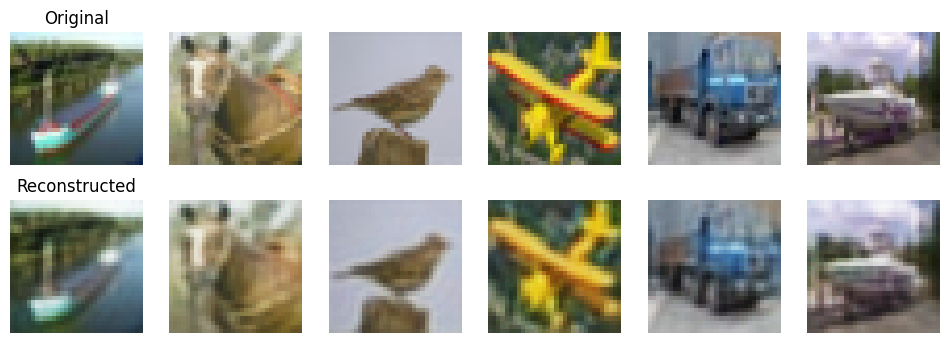

In [ ]:
def denorm(x):
    return x * 0.5 + 0.5  # [-1,1] -> [0,1]

model.eval()
with torch.no_grad():
    imgs, _ = next(iter(loader))
    imgs = imgs.to(device)
    outputs = model(imgs)

imgs = denorm(imgs.cpu())
outputs = denorm(outputs.cpu())

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):
    axes[0, i].imshow(np.transpose(imgs[i], (1,2,0)))
    axes[0, i].axis("off")

    axes[1, i].imshow(np.transpose(outputs[i], (1,2,0)))
    axes[1, i].axis("off")

axes[0,0].set_title("Original")
axes[1,0].set_title("Reconstructed")

plt.show()